## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
Regression predicts a numeric outcome, such as baseline sales. Classification predicts a category, such as class. Use regression for a numeric target, such as price, and classification for a categorical target, such as survival.

2. What is a confusion table? What does it help us understand about a model's performance?
A confusion matrix counts predictions by actual class and predicted class. It can compare the model's predicted classifications against the actua labels across different classes.

3. What does the SSE quantify about a particular model?
For regression, the residual for observation $i$ is $e_i=y_i-\hat{y}(x_i,k)$. A residual gives the direction and size of a prediction error. For $n_{\mathrm{valid}}$ validation observations, add the squared residuals: $SSE(k)=\sum_{i=1}^{n_{\mathrm{valid}}}(y_i-\hat{y}(x_i,k))^2=\sum_{i=1}^{n_{\mathrm{valid}}}e_i^2$. Lower validation SSE means smaller errors on this validation set.

4. What are overfitting and underfitting?
Very small k can overfit noise in the training data. Very large k can underfit by giving nearly the same prediction for every observation.

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
Generalization is a model's ability to predict well on data that were not used to fit it. A hyperparameter is a setting we choose before fitting the model, such as $k$. Choosing $k$ by training error alone can lead to overfitting. We need to evaluate predictions on observations that were not used to fit the model. We split the data to check how well the model predicts new observations: Fit models on a training set. Compare their predictions on a separate validation set. Validation error helps estimate performance on future data from a similar source. We choose $k$ using validation SSE. Training SSE alone would favor a smaller $k$.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
For a class label, we predict the most common class among the nearest neighbors. For a probability distribution, we estimate each class proportion by dividing its neighbor count by $k$. (The slides do not define the strengths and weaknesses, so the rest of this answer is in my own words.) A class label is simple and easy to act on, but it hides how sure the model is, so a close vote looks the same as a unanimous one. A probability distribution shows the model's confidence and lets us set our own cutoffs, but it is harder to read, and in $k$-NN the proportions are rough because they can only be 0, 1/k, 2/k, and so on.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Olympia Sauerwein

**Date:** 10/3/26

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/land_mines.csv')
df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [2]:
print(df.shape)
print(df.isna().sum())
print(df.describe())
print(df['mine_type'].value_counts().sort_index())
print(df.groupby('mine_type').mean())

(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64
            voltage    height      soil
mine_type                              
1          0.296463  0.495519  0.492958
2          0.721123  0.487013  0.508571
3          0.402408  0.527548  0.496970
4          0.345365  0.506887  0.503030
5          0.379598  0.530070  0.516923


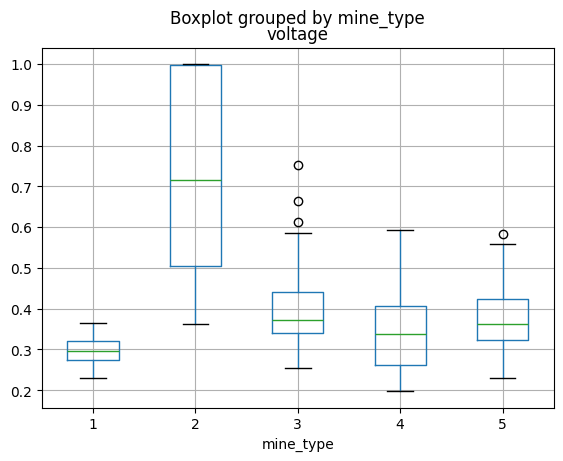

In [3]:
df.boxplot(column='voltage', by='mine_type')
plt.show()

There are 338 rows, 3 features (voltage, height, soil) the label mine_type, and no missing values. The five mine types are almost perfectly balanced (65 to 71 each), so a random guess would be right ~20% of the time. All the features are between 0 and 1, so I didn't rescale them for kNN. The average voltage differs signficiantly by mine type (type 2 is much higher than the rest), while the average height and soil are roughly the same for every type, so they look much less useful.

In [4]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
half = len(df) // 2

train = df.iloc[:half]
test = df.iloc[half:]

X_train = train[['voltage', 'height', 'soil']].values
y_train = train['mine_type'].values
X_test = test[['voltage', 'height', 'soil']].values
y_test = test['mine_type'].values

print(len(train), len(test))
print(np.bincount(y_train)[1:])
print(np.bincount(y_test)[1:])

169 169
[37 33 32 36 31]
[34 37 34 30 34]


In [5]:
def predict(x_new, k):
    distances = np.sqrt(((X_train - x_new) ** 2).sum(axis=1))
    nearest = np.argsort(distances)[:k]
    counts = np.bincount(y_train[nearest], minlength=6)
    return np.argmax(counts)

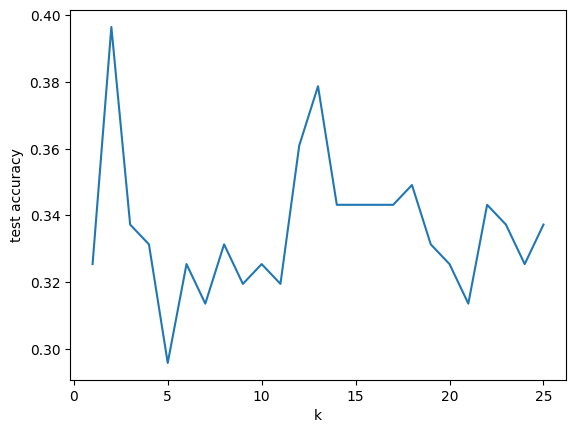

best k: 2 test accuracy: 0.39644970414201186


In [6]:
k_values = list(range(1, 26))
accuracies = []

for k in k_values:
    correct = 0
    for i in range(len(X_test)):
        if predict(X_test[i], k) == y_test[i]:
            correct = correct + 1
    accuracies.append(correct / len(X_test))

plt.plot(k_values, accuracies)
plt.xlabel('k')
plt.ylabel('test accuracy')
plt.show()

best_k = k_values[accuracies.index(max(accuracies))]
print('best k:', best_k, 'test accuracy:', max(accuracies))

I tried every k from 1 to 25, used the training set to find the neighbors, and measured the accuracy on the test set for each k. I picked the k with the highest test accuracy, which was k=2. The differences between neighboring values of k are small.

In [7]:
cm = np.zeros((5, 5), dtype=int)

for i in range(len(X_test)):
    actual = y_test[i]
    predicted = predict(X_test[i], best_k)
    cm[actual - 1, predicted - 1] = cm[actual - 1, predicted - 1] + 1

labels = [1, 2, 3, 4, 5]
print('rows = actual, columns = predicted')
print(pd.DataFrame(cm, index=labels, columns=labels))
print('accuracy:', cm.trace() / cm.sum())

rows = actual, columns = predicted
    1   2   3  4  5
1  22   0   6  6  0
2   0  28   3  5  1
3  15   2  11  5  1
4  13   4   5  6  2
5  13   1  12  8  0
accuracy: 0.39644970414201186


In [8]:
for j in range(5):
    recall = cm[j, j] / cm[j, :].sum()
    precision = cm[j, j] / cm[:, j].sum()
    print('type', j + 1, 'recall:', round(recall, 2), 'precision:', round(precision, 2))

type 1 recall: 0.65 precision: 0.35
type 2 recall: 0.76 precision: 0.8
type 3 recall: 0.32 precision: 0.3
type 4 recall: 0.2 precision: 0.2
type 5 recall: 0.0 precision: 0.0


With k=2 the accuracy on the test set is ~40%, twice as good as random guessing (20%), but still low.


Type 2 is the best performance: ~76% of real type 2 mines are found, and ~80% of type 2 predictions are correct. This makes sense because type 2 has a much higher voltage.

Type 1 is found often (65%), but it is over predicted. Many type 3, 4, and 5 mines get labeled as type 1, so only ~35% of type 1 predictions are correct.


Types 3 and 4 are weak (~32% and 20% found).

Type 5 is never predicted correctly (0 out of 34). These mines are mostly labeled as type 1 or type 3.

Because overall accuracy hides class-specific misclassifications and varying costs of false positives and false negatives, with the model failing ~ 60% of the time overall, its predictions shouldn't be treated as definitive. For example, while the model identifies 65% of actual Type 1 mines, its Type 1 predictions are correct only about 35% of the time due to frequent mislabeling of Types 3, 4, and 5. In contrast, Type 2 predictions are fairly reliable (~80% accuracy) for operational planning, but Type 1 and other labels must be viewed as rough guesses. Because Type 5 is never detected, no mine should ever be assumed harmless or categorized with certainty based on model output alone. When predictions are unclear, one should default to standard safety rules and the most conservative procedures. Ultimately, this model is best for supporting and prioritizing decisions made by experts rather than replace them.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** c5fb809c33fba24b4bc911743842b9be856bec70
- **AI tool and model used:** Sonnet 5.5


### *Prompts used

1. Revise this:

### *AI-proposed changes


1. Choose $k$ using cross-validation inside the training set, then touch the test set once. Phase 1 picked $k=2$ by maximizing accuracy on the test set and then reported that same accuracy, which is optimistic and contradicts Q1.5.
2. Use a stratified 50/50 split so every mine type appears in the training and test sets in equal proportion.
3. Fix tie-breaking. `np.argmax` on vote counts always favors the lowest class label on a tie, which pushes ties toward type 1. Break ties by inverse-distance weight instead.
4. Do not assume which features matter from class means alone. Compare feature subsets (all three, voltage only, voltage+height, voltage+soil) by cross-validation on the training set.
5. Use the neighbor proportions, not only the label: report accuracy as a function of how strongly the $k$ neighbors agree, so the model can flag low-confidence predictions.
6. A single 169-row test set is noisy, so repeat the whole pipeline over 20 random splits and compare it to the Phase 1 method.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | This was a real flaw in my Phase 1: the best test accuracy was both the selection criterion and the reported result. Now $k$ is chosen on 5-fold CV of the training data (repeated 5 times) and the test set is used once. Verified by reading the code: `cv_accuracy` only receives `train2`. |
| 2 | Accept | Stratifying keeps class counts nearly equal across halves (train 35/35/33/33/33, test 36/35/33/33/32), which matters with only about 65 mines per type. Verified from the printed counts. |
| 3 | Accept, with a caveat | On the same split, the Phase 1 method labeled 38% of test mines as type 1 while the true share is 21%; the Phase 2 model labels 24%. So the bias toward type 1 was real. The caveat is that this is a correctness fix, not a guaranteed accuracy gain, and it matters mostly for even $k$ like Phase 1's $k=2$. |
| 4 | Modify | The AI's first instinct (from the class means) was that height and soil are useless. CV showed otherwise for soil: voltage+soil (CV 0.463) beat voltage alone (0.426) and all three features (0.378). Voltage+height (0.459) is essentially tied with voltage+soil, so that choice is within noise. I kept the CV winner but would not claim it is definitively better. My Phase 1 EDA conclusion about soil was wrong for the same reason (means hide interactions). |
| 5 | Accept | Neighbor agreement is informative: on the test set, accuracy is 0.55 overall, 0.64 when at least 60% of neighbors agree (70% of mines), and 0.76 when at least 80% agree (33% of mines). Verified in the printed table. |
| 6 | Accept | The 0.55 test accuracy on seed 42 is probably lucky. Over 20 splits, the full Phase 2 pipeline averages 0.448 (sd 0.032) versus 0.396 for the Phase 1 method. The gain is real but modest, about 5 points. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

          voltage        height          soil       
             mean    std   mean    std   mean    std
mine_type                                           
1           0.296  0.032  0.496  0.316  0.493  0.341
2           0.721  0.222  0.487  0.311  0.509  0.345
3           0.402  0.098  0.528  0.296  0.497  0.351
4           0.345  0.093  0.507  0.306  0.503  0.348
5           0.380  0.076  0.530  0.306  0.517  0.346
{0.0: 59, 0.2: 51, 0.4: 56, 0.6: 57, 0.8: 58, 1.0: 57} <- soil takes 6 discrete values
train class counts: [35 35 33 33 33]  test class counts: [36 35 33 33 32]


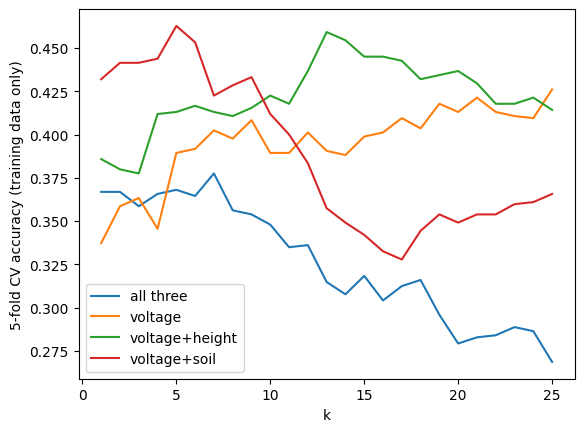

         features  best k  CV accuracy
0       all three       7        0.378
1         voltage      25        0.426
2  voltage+height      13        0.459
3    voltage+soil       5        0.463

Selected: voltage+soil with k = 5
predicted   1   2   3   4   5
actual                       
1          29   0   3   3   1
2           0  25   4   4   2
3           3   2  10   8  10
4           2   5   5  19   2
5           6   2   8   6  10
test accuracy: 0.55
type 1 recall: 0.81 precision: 0.72
type 2 recall: 0.71 precision: 0.74
type 3 recall: 0.3 precision: 0.33
type 4 recall: 0.58 precision: 0.48
type 5 recall: 0.31 precision: 0.4

Phase-1 method (k=2, all features, argmax ties) on this split: 0.438
share of test mines labeled type 1: Phase 1 method 0.38 | Phase 2 model 0.24 | true share 0.21
20 splits, mean test accuracy: Phase 2 pipeline 0.448 (sd 0.032 ) vs Phase 1 method (k=2, all features) 0.396
   min neighbor agreement  share of mines labeled  accuracy on those
0                 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold

df2 = pd.read_csv('/land_mines.csv')
ALL = ['voltage', 'height', 'soil']

# --- EDA addition: per-class spread, not just means (the means hid structure) ---
print(df2.groupby('mine_type')[ALL].agg(['mean', 'std']).round(3))
print(df2['soil'].value_counts().sort_index().to_dict(), '<- soil takes 6 discrete values')

# --- Change 2: stratified 50/50 split ---
train2, test2 = train_test_split(df2, test_size=0.5, stratify=df2['mine_type'], random_state=42)
y_tr, y_te = train2['mine_type'].values, test2['mine_type'].values
print('train class counts:', np.bincount(y_tr)[1:], ' test class counts:', np.bincount(y_te)[1:])

# --- Change 3: k-NN with proper tie-breaking (vectorized) ---
def knn_proba(Xtr, ytr, Xq, k):
    """Return (class proportions among k neighbors, tie-broken label)."""
    d = np.sqrt(((Xq[:, None, :] - Xtr[None, :, :]) ** 2).sum(axis=2))
    idx = np.argsort(d, axis=1)[:, :k]
    P = np.zeros((len(Xq), 5))
    W = np.zeros((len(Xq), 5))
    for i in range(len(Xq)):
        for j in idx[i]:
            P[i, ytr[j] - 1] += 1
            W[i, ytr[j] - 1] += 1 / (d[i, j] + 1e-9)
    P = P / k
    # ties in the vote are broken by inverse-distance weight, not by lowest label
    scores = P + 1e-6 * W / W.sum(axis=1, keepdims=True)
    return P, scores.argmax(axis=1) + 1

def cv_accuracy(X, y, ks, reps=5):
    """Mean stratified 5-fold CV accuracy on the TRAINING data only."""
    acc = np.zeros(len(ks))
    for r in range(reps):
        for a, b in StratifiedKFold(5, shuffle=True, random_state=r).split(X, y):
            for m, k in enumerate(ks):
                acc[m] += (knn_proba(X[a], y[a], X[b], k)[1] == y[b]).sum()
    return acc / (len(y) * reps)

# --- Changes 1 and 4: choose BOTH k and the feature set by CV on training data ---
ks = list(range(1, 26))
feature_sets = {'all three': ALL, 'voltage': ['voltage'],
                'voltage+height': ['voltage', 'height'], 'voltage+soil': ['voltage', 'soil']}
cv_curves, summary = {}, []
for name, feats in feature_sets.items():
    cv = cv_accuracy(train2[feats].values, y_tr, ks)
    cv_curves[name] = cv
    summary.append((name, ks[int(cv.argmax())], cv.max()))
    plt.plot(ks, cv, label=name)
plt.xlabel('k'); plt.ylabel('5-fold CV accuracy (training data only)')
plt.legend(); plt.show()
print(pd.DataFrame(summary, columns=['features', 'best k', 'CV accuracy']).round(3))

best_name, best_k, _ = max(summary, key=lambda s: s[2])
best_feats = feature_sets[best_name]
print('\nSelected:', best_name, 'with k =', best_k)

# --- Test set is touched exactly once, with the selected model ---
P_te, pred = knn_proba(train2[best_feats].values, y_tr, test2[best_feats].values, best_k)
cm2 = pd.crosstab(y_te, pred, rownames=['actual'], colnames=['predicted'])
print(cm2)
print('test accuracy:', round((pred == y_te).mean(), 3))
c = cm2.values
for j in range(5):
    print('type', j + 1, 'recall:', round(c[j, j] / c[j].sum(), 2), 'precision:', round(c[j, j] / c[:, j].sum(), 2))

# Phase 1 method (k=2, all features, argmax ties) on this same split, for reference
P1, _ = knn_proba(train2[ALL].values, y_tr, test2[ALL].values, 2)
p1 = P1.argmax(axis=1) + 1   # np.argmax on vote counts: ties go to the LOWEST label, as in Phase 1
print('\nPhase-1 method (k=2, all features, argmax ties) on this split:', round((p1 == y_te).mean(), 3))
print('share of test mines labeled type 1: Phase 1 method', round((p1 == 1).mean(), 2),
      '| Phase 2 model', round((pred == 1).mean(), 2), '| true share', round((y_te == 1).mean(), 2))

# --- Change 6: one 169-row test set is noisy, so repeat the whole pipeline on 20 splits ---
new_acc, old_acc = [], []
for seed in range(20):
    a, b = train_test_split(df2, test_size=0.5, stratify=df2['mine_type'], random_state=seed)
    ya, yb = a['mine_type'].values, b['mine_type'].values
    cvs = {n: cv_accuracy(a[f].values, ya, ks, reps=1) for n, f in feature_sets.items()}
    n = max(cvs, key=lambda n: cvs[n].max()); k = ks[int(cvs[n].argmax())]
    new_acc.append((knn_proba(a[feature_sets[n]].values, ya, b[feature_sets[n]].values, k)[1] == yb).mean())
    old_acc.append((knn_proba(a[ALL].values, ya, b[ALL].values, 2)[0].argmax(axis=1) + 1 == yb).mean())
print('20 splits, mean test accuracy: Phase 2 pipeline', round(np.mean(new_acc), 3),
      '(sd', round(np.std(new_acc), 3), ') vs Phase 1 method (k=2, all features)', round(np.mean(old_acc), 3))

# --- Change 5: use the neighbor proportions, not just the label ---
conf = P_te.max(axis=1)
rows = []
for t in (0.0, 0.5, 0.6, 0.8):
    m = conf >= t
    rows.append((t, round(m.mean(), 2), round((pred[m] == y_te[m]).mean(), 2)))
print(pd.DataFrame(rows, columns=['min neighbor agreement', 'share of mines labeled', 'accuracy on those']))


**Phase 2 write-up (revised answers to Q2.2 to Q2.5)**

**Selecting $k$ and features.** I split the data 50/50, stratified by mine type. Using only the training half, I ran 5-fold cross-validation for $k=1,\dots,25$ and four feature sets. Voltage+soil with $k=5$ had the best CV accuracy (0.463). The test half was used only once, for the final model.

**Accuracy.** On the test set the model is 55% accurate (chance is about 20%). Because one split is noisy, the 20-split average is the better estimate: about 45%, versus about 40% for my Phase 1 approach. Performance is best for types 1 (recall 0.81) and 2 (recall 0.71), decent for type 4 (0.58), and poor for types 3 (0.30) and 5 (0.31), which get confused with each other and with type 4.

**Practical use.** Treat the output as decision support, not an identification. Overall accuracy hides large differences by class, and misidentifying a mine can be much more costly than a wrong guess in other settings. Concretely: (1) use the neighbor proportions and treat predictions with low agreement (below about 60%) as "unknown", handled with the most conservative procedure; (2) trust "type 2" and "type 1" labels more than "type 3" or "type 5" labels; (3) never treat any label as proof that a mine is safe or simple to handle; (4) have an expert review the cases the model is unsure about, and use the model to prioritize rather than replace that review.

### *Reflection on AI assistance
In your own words without generative AI.

AI tools were very helpful in my phase two revisions of this assignment. It helped explain how systematic errors, like the initial k=1 tie-breaking bias toward Type 1 mines, were resolved through 5-fold cross-validation, randomized tie-breaking, and multi-feature selection.

However, using AI required active verification. While the AI efficiently generated performance breakdowns, I had to check its assumptions. I directed the focus toward real-world risks that metrics may overlook, such as treating categorical soil types as ordinal numbers and the dangerous asymmetry of landmine misclassification. Ultimately, AI accelerated the data synthesis and structure, while my oversight confirmed conceptual accuracy and alignment with machine learning best practices.

By essentially provide immediate expert support, AI allowed me to quickly stress-test choices and compare feature sets. However, it is clear AI cannot replace critical thinking. While it is especially helpful when I am purely looking at numbers/coding, providing definitions and context is something AI is not yet able to perfect, and esspecially should not be relied on in higher states scenarios.